In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time

In [110]:
df = pd.read_csv("../Data/2_lab_proc.csv", index_col=False)

In [111]:
df.head()

,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,...,name_pca_22,name_pca_23,name_pca_24,name_pca_25,name_pca_26,name_pca_27,name_pca_28,name_pca_29,name_pca_30,name_pca_31
0,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,...,0.006792,-0.028298,0.079597,0.073711,-0.010413,0.093791,0.029102,0.043787,0.040946,0.097439
1,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",NaN,https://shared.akamai.steamstatic.com/store_it...,...,-0.137145,-0.068856,-0.060226,-0.004427,0.023389,-0.027792,-0.080691,0.004238,-0.029277,-0.056910
2,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,NaN,https://shared.akamai.steamstatic.com/store_it...,...,0.084395,-0.015606,0.246815,0.012492,-0.099663,0.092128,0.059948,0.084477,0.003469,-0.044166
3,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,NaN,https://shared.akamai.steamstatic.com/store_it...,...,-0.031149,0.011949,0.178109,0.099992,0.031411,0.108465,-0.101274,-0.075410,-0.066593,-0.007429
4,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,NaN,https://shared.akamai.steamstatic.com/store_it...,...,0.032869,-0.109430,-0.061249,-0.020546,-0.194967,0.086971,0.055591,0.084937,-0.073262,-0.114326


In [112]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 74 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   name                      122610 non-null  object 
 1   release_date              122611 non-null  object 
 2   required_age              122611 non-null  int64  
 3   price                     122611 non-null  float64
 4   dlc_count                 122611 non-null  int64  
 5   detailed_description      114191 non-null  object 
 6   about_the_game            114163 non-null  object 
 7   short_description         114302 non-null  object 
 8   reviews                   12070 non-null   object 
 9   header_image              122530 non-null  object 
 10  website                   49676 non-null   object 
 11  support_url               54142 non-null   object 
 12  support_email             100348 non-null  object 
 13  windows                   122611 non-null  b

In [113]:
df.describe()

,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,negative,...,name_pca_22,name_pca_23,name_pca_24,name_pca_25,name_pca_26,name_pca_27,name_pca_28,name_pca_29,name_pca_30,name_pca_31
count,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,122611.000000,40.000000,1.226110e+05,1.226110e+05,...,1.226110e+05,1.226110e+05,1.226110e+05,1.226110e+05,1.226110e+05,1.226110e+05,1.226110e+05,1.226110e+05,1.226110e+05,1.226110e+05
mean,0.167611,4.765091,0.545856,2.564941,18.087015,9.618250e+02,0.024549,99.175000,1.044986e+03,1.691974e+02,...,2.284510e-07,-6.877879e-08,-1.020139e-07,2.000481e-07,7.610327e-08,1.584525e-07,-1.074099e-07,4.823164e-08,5.416120e-08,2.278992e-08
std,1.653591,12.531030,14.516026,13.660559,141.493879,2.187880e+04,1.394901,0.675107,2.809173e+04,5.374645e+03,...,8.106552e-02,8.025125e-02,7.905454e-02,7.874118e-02,7.773577e-02,7.737642e-02,7.675919e-02,7.636491e-02,7.596159e-02,7.562107e-02
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,0.000000e+00,...,-3.561834e-01,-3.411138e-01,-3.703613e-01,-3.208835e-01,-3.355624e-01,-3.406034e-01,-3.275972e-01,-3.453457e-01,-3.364915e-01,-3.036346e-01
25%,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,0.000000e+00,0.000000e+00,...,-5.311412e-02,-5.364700e-02,-5.326284e-02,-5.420821e-02,-5.120309e-02,-5.057996e-02,-5.114137e-02,-5.117127e-02,-4.969895e-02,-5.104724e-02
50%,0.000000,2.240000,0.000000,0.000000,2.000000,0.000000e+00,0.000000,99.000000,5.000000e+00,1.000000e+00,...,6.413143e-04,-2.884977e-04,-1.197573e-03,-2.987027e-03,-8.117734e-04,1.036810e-03,-1.108538e-03,-7.203035e-04,2.138633e-04,-4.660450e-04
75%,0.000000,5.240000,0.000000,0.000000,19.000000,0.000000e+00,0.000000,100.000000,3.700000e+01,1.000000e+01,...,5.320713e-02,5.255489e-02,5.205457e-02,5.141569e-02,5.116879e-02,5.196194e-02,4.968958e-02,5.078845e-02,5.016309e-02,5.048529e-02
max,21.000000,999.980000,3703.000000,97.000000,9821.000000,4.830455e+06,100.000000,100.000000,7.642084e+06,1.173003e+06,...,3.434853e-01,3.473643e-01,3.623635e-01,3.653043e-01,3.429418e-01,3.208105e-01,3.575927e-01,3.290209e-01,3.184042e-01,3.433026e-01


## Мусорные данные Header image

In [114]:
df["header_image"]

0         https://shared.akamai.steamstatic.com/store_it...
1         https://shared.akamai.steamstatic.com/store_it...
2         https://shared.akamai.steamstatic.com/store_it...
3         https://shared.akamai.steamstatic.com/store_it...
4         https://shared.akamai.steamstatic.com/store_it...
                                ...                        
122606    https://shared.akamai.steamstatic.com/store_it...
122607    https://shared.akamai.steamstatic.com/store_it...
122608    https://shared.akamai.steamstatic.com/store_it...
122609    https://shared.akamai.steamstatic.com/store_it...
122610    https://shared.akamai.steamstatic.com/store_it...
Name: header_image, Length: 122611, dtype: object

In [115]:
df = df.drop(["header_image"], axis=1)

## Мусорные данные Name, Reviews

Удаляю Name, уже сделал embending

In [116]:
df = df.drop(labels=["name"], axis=1)

In [117]:
df["reviews"].value_counts()

reviews
“🏆 I loved! ❤️❤️❤️” Player “🏆 Cute kittens, easy to play, great for relaxing 😄😺❤️” Nikky                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 43
“” Read more on PC Gamer                                                                                                                            

#### Лучше удалить, так как дальнейшие колонки уже содержут эту информацию

In [118]:
df = df.drop(labels=["reviews"], axis=1)

## Мусорные данные Supported languages, Full audio languages

In [119]:
df["supported_languages"] = df["supported_languages"].str.replace(r"[\[\]'\"]", "", regex=True).apply(
    lambda x: len([i for i in str(x).split(',') if i.strip()]))

In [120]:
df["full_audio_languages"] = df["full_audio_languages"].str.replace(r"[\[\]'\"]", "", regex=True).apply(
    lambda x: len([i for i in str(x).split(',') if i.strip()]))

In [121]:
df[["supported_languages", "full_audio_languages"]]

,supported_languages,full_audio_languages
0,0,0
1,1,0
2,4,0
3,1,1
4,1,1
...,...,...
122606,2,2
122607,4,2
122608,1,1
122609,2,2


## Данные Estimated owners 

In [122]:
df["estimated_owners"] = df["estimated_owners"].apply(lambda x: sum([int(i.strip()) for i in x.split('-') if i.strip()])/2)

In [123]:
df["estimated_owners"].describe()

count    1.226110e+05
mean     8.571967e+04
std      1.289682e+06
min      0.000000e+00
25%      1.000000e+04
50%      1.000000e+04
75%      1.000000e+04
max      1.500000e+08
Name: estimated_owners, dtype: float64

## Данные Release date

In [124]:
df["release_date"] = pd.to_datetime(df["release_date"])

df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

df["release_date"]

0        2023-08-01
1        2016-07-29
2        2019-05-06
3        2024-10-31
4        2025-04-24
            ...    
122606   2026-01-04
122607   2026-01-03
122608   2026-01-03
122609   2026-01-04
122610   2026-01-05
Name: release_date, Length: 122611, dtype: datetime64[ns]

In [125]:
time_ = time.localtime()
time_format = pd.to_datetime(f"{time_.tm_year}-{time_.tm_mon}-{time_.tm_wday}")
df["days_since_release"] = (time_format - df["release_date"]).dt.days

In [126]:
df["days_since_release"]

0          947
1         3506
2         2495
3          490
4          315
          ... 
122606      60
122607      61
122608      61
122609      60
122610      59
Name: days_since_release, Length: 122611, dtype: int64

In [128]:
df = df.drop(["release_date"], axis=1)

KeyError: "['release_date'] not found in axis"

## Данные Website, Support url, Support email, Windows, Mac, Linux, Metactritic score, Metacritic url


In [129]:
df["website"] # стоит удалить

0                                                 NaN
1                      http://mangagamer.org/supipara
2               https://www.facebook.com/8FloorGames/
3                                                 NaN
4         https://www.realityexpanded.com/books-games
                             ...                     
122606                                            NaN
122607                     https://www.pokerfate.com/
122608            https://arraubigameware.com/home-3/
122609                                            NaN
122610                                            NaN
Name: website, Length: 122611, dtype: object

In [130]:
df[["support_url", "support_email"]]# стоит удалить

,support_url,support_email
0,NaN,NaN
1,http://mangagamer.com,support@mangagamer.com
2,https://www.facebook.com/8FloorGames,support@8floor.net
3,NaN,yujingamesc@gmail.com
4,https://www.realityexpanded.com,support@realityexpanded.com
...,...,...
122606,NaN,yuanhao@taoxinsoft.com
122607,https://www.pokerfate.com,info@pokerfate.com
122608,https://arraubigameware.com/,argameware@gmail.com
122609,NaN,support@sevenmoons.com.br


In [131]:
df = df.drop(["support_url", "support_email", "website"], axis=1)

In [132]:
df["windows"] # проще считать что все играют на win, >97% на нем играют

0         True
1         True
2         True
3         True
4         True
          ... 
122606    True
122607    True
122608    True
122609    True
122610    True
Name: windows, Length: 122611, dtype: bool

In [133]:
df = df.drop(["windows","mac","linux"],axis=1)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 67 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   required_age              122611 non-null  int64  
 1   price                     122611 non-null  float64
 2   dlc_count                 122611 non-null  int64  
 3   detailed_description      114191 non-null  object 
 4   about_the_game            114163 non-null  object 
 5   short_description         114302 non-null  object 
 6   metacritic_score          122611 non-null  int64  
 7   metacritic_url            4256 non-null    object 
 8   achievements              122611 non-null  int64  
 9   recommendations           122611 non-null  int64  
 10  notes                     22458 non-null   object 
 11  supported_languages       122611 non-null  int64  
 12  full_audio_languages      122611 non-null  int64  
 13  packages                  122611 non-null  o

## Данные Required age, About the game, Achievements 

In [135]:
df["required_age"] = df["required_age"].apply(lambda x: 1 if x >=18 else 0)
#пока решил оставить

In [136]:
df["about_the_game"] # все это же содержится в positive и negative

0                                                       NaN
1         Springtime, April: when the cherry trees come ...
2         Immerse yourself in the most beloved, mystical...
3         synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...
4         Its not just a Maze; its a Quest! Enter the ca...
                                ...                        
122606    《完美传奇》游戏介绍 🔥【完美传奇——专属大陆的奇幻史诗！】🔥 🌍耗时两年匠心打造，诚意之作...
122607    Poker Fate – Choose your poker partner and ent...
122608    (Gif character) Adira Nusantara is a side-scro...
122609    Step into the role of Arariboia, a legendary I...
122610    Exhibited at Vantan Game Academy – TOKYO GAME ...
Name: about_the_game, Length: 122611, dtype: object

In [137]:
df = df.drop(["about_the_game"], axis=1)

In [138]:
df = df.drop(["achievements"],axis=1) # их просто слииишком мало
# да и кол во достижений ниуву не коррелирует

In [31]:
df["user_score"].describe() #данные разряжены

count    122611.000000
mean          0.024549
std           1.394901
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         100.000000
Name: user_score, dtype: float64

In [139]:
df = df.drop(["user_score"], axis=1)

In [140]:
df = df.drop(["score_rank"], axis=1)

In [141]:
df["metacritic_url"] = df["metacritic_url"].notna().astype(int)

## Positive, Negative, Developers, Сategories, Publishers

In [142]:
df["positive"].describe()

count    1.226110e+05
mean     1.044986e+03
std      2.809173e+04
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+00
75%      3.700000e+01
max      7.642084e+06
Name: positive, dtype: float64

In [143]:
df["negative"].describe()

count    1.226110e+05
mean     1.691974e+02
std      5.374645e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+01
max      1.173003e+06
Name: negative, dtype: float64

In [144]:
df["persent_positive"] = df["positive"]/(df["positive"] + df["negative"])

In [146]:
df["persent_positive"] = df["persent_positive"].fillna(0)
df["persent_positive"]

0         0.000000
1         0.988235
2         0.875000
3         0.000000
4         0.000000
            ...   
122606    0.000000
122607    0.000000
122608    0.000000
122609    0.000000
122610    0.000000
Name: persent_positive, Length: 122611, dtype: float64

In [ ]:
# все средние и медианные времена игр оставляю

In [147]:
df["developers"]

0                                         []
1                                 ['minori']
2                            ['Somer Games']
3                                  ['유진게임즈']
4                   ['Reality Expanded LLC']
                         ...                
122606                              ['完美传奇']
122607    ['©7 Points Digital Tech Limited']
122608                  ['Arraubi Gameware']
122609                       ['Seven Moons']
122610               ['Vantan Game Academy']
Name: developers, Length: 122611, dtype: object

In [148]:
df["developers"] = df["developers"].str.replace("[", "").str.replace("]", "").str.replace(" ", "")
df["developers"] = df["developers"].replace('', np.nan)

In [149]:
df['developers'] = df['developers'].fillna('Unknown')
top_devs = df['developers'].value_counts().nlargest(10).index
df['developers_grouped'] = df['developers'].apply(lambda x: x if x in top_devs else 'Other')
df["developers_grouped"].value_counts()

developers_grouped
Other                       112833
Unknown                       8431
'EroticGamesClub'              231
'ChoiceofGames'                179
'BoogygamesStudios'            157
'LaushDmitriySergeevich'       150
'Creobit'                      137
'BullyRevengeStudios'          135
'Gamesforgames'                123
'HostedGames'                  118
'CyberKeks'                    117
Name: count, dtype: int64

In [150]:
dev_dummies = pd.get_dummies(df['developers_grouped'], prefix='dev')
df = pd.concat([df, dev_dummies], axis=1)
df = df.drop(["developers", "developers_grouped"], axis=1)

In [151]:
df = df.drop(["dev_Other", "dev_Unknown"], axis=1)

In [152]:
df["publishers"] = df["publishers"].str.replace("[", "").str.replace("]", "").str.replace(" ", "")
df["publishers"] = df["publishers"].replace('', np.nan)
df['publishers'] = df['publishers'].fillna('Unknown')

top_devs = df['publishers'].value_counts().nlargest(10).index
df['publishers_grouped'] = df['publishers'].apply(lambda x: x if x in top_devs else 'Other')
df["publishers_grouped"].value_counts()

dev_dummies = pd.get_dummies(df['publishers_grouped'], prefix='pub')
df = pd.concat([df, dev_dummies], axis=1)
df = df.drop(["publishers", "publishers_grouped"], axis=1)

df = df.drop(["pub_Other", "pub_Unknown"], axis=1)

##  Муссорные данные: Tags, Screenshots, Movies, Packges, Notes

In [153]:
df["movies"].value_counts() #пон

movies
[]    122611
Name: count, dtype: int64

In [154]:
df["tags"]

0                                                        []
1         {'Adventure': 27, 'Visual Novel': 19, 'Anime':...
2         {'Casual': 83, 'Card Game': 52, 'Solitaire': 4...
3                                                        []
4                                                        []
                                ...                        
122606                                                   []
122607                                                   []
122608                                                   []
122609                                                   []
122610                                                   []
Name: tags, Length: 122611, dtype: object

In [155]:
df = df.drop(["tags", "movies", "packages", "screenshots", "notes"], axis=1)

In [156]:
len(df.columns)

75

## Short_description и Detailed_description

In [49]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

In [51]:
model = SentenceTransformer("all-MiniLM-l6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-l6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [52]:
embendings = model.encode(df["short_description"].astype(str).tolist(), batch_size=64, show_progress_bar=True)

Batches:   0%|          | 0/1916 [00:00<?, ?it/s]

In [81]:
embendings.shape

(122611, 384)

In [54]:
n_comp = 5
pca = PCA(n_components=n_comp)
pca_features = pca.fit_transform(embendings)

In [157]:
pca_cols = [f'name_desc_{i}' for i in range(n_comp)]
df_pca = pd.DataFrame(pca_features, columns=pca_cols, index=df.index)

df = pd.concat([df, df_pca], axis=1)

In [158]:
df = df.drop(["detailed_description"], axis=1)

In [159]:
df = df.drop(["short_description"], axis=1)

## Genres и categories

In [160]:
df["genres"]

0                                                        []
1                                             ['Adventure']
2                                                ['Casual']
3                         ['Casual', 'Indie', 'Simulation']
4                                ['Action', 'Early Access']
                                ...                        
122606    ['Action', 'Adventure', 'Massively Multiplayer...
122607               ['Casual', 'Strategy', 'Free To Play']
122608    ['Action', 'Adventure', 'Casual', 'Early Access']
122609           ['Action', 'Adventure', 'Casual', 'Indie']
122610                  ['Action', 'Indie', 'Free To Play']
Name: genres, Length: 122611, dtype: object

In [161]:
df["categories"]

0                                                        []
1         ['Single-player', 'Steam Trading Cards', 'Stea...
2                       ['Single-player', 'Family Sharing']
3         ['Single-player', 'Steam Achievements', 'Famil...
4         ['Single-player', 'VR Only', 'Steam Leaderboar...
                                ...                        
122606    ['Single-player', 'Multi-player', 'MMO', 'PvP'...
122607    ['Multi-player', 'PvP', 'Online PvP', 'Cross-P...
122608    ['Single-player', 'Custom Volume Controls', 'N...
122609    ['Single-player', 'Full controller support', '...
122610      ['Single-player', 'Partial Controller Support']
Name: categories, Length: 122611, dtype: object

In [162]:
import ast

In [163]:
df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [164]:
top_five = df["genres"].explode().value_counts().nlargest(5).index.to_list()
top_five

['Indie', 'Casual', 'Action', 'Adventure', 'Simulation']

In [165]:
for genre in top_five:
    
    df[f'genre_{genre}'] = df['genres'].apply(lambda x: 1 if genre in x else 0)

In [166]:
df['categories'] = df['categories'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
#temp_df = df[['categories', 'peak_ccu']].explode('categories')
#genre_stats = temp_df.groupby('categories')['peak_ccu'].agg(['mean', 'count'])

#top_5_by_online = genre_stats[genre_stats['count'] > 50] \
 #   .nlargest(5, 'mean').index.tolist()

In [167]:
top_5 = df['categories'].explode().value_counts().nlargest(5).index.to_list()

In [ ]:
#temp_df.groupby('categories')['peak_ccu'].agg(['mean', 'count'])

,mean,count
categories,,
Adjustable Difficulty,278.770356,2530
Adjustable Text Size,2105.015504,774
Camera Comfort,997.603045,2824
Captions available,198.265951,1583
Chat Speech-to-text,6943.689655,29
Chat Text-to-speech,1944.657143,35
Co-op,316.149651,11019
Color Alternatives,1556.940289,1524
Commentary available,259.656463,294


In [ ]:
#genre_stats[genre_stats['count'] > 50] \
 #   .nlargest(5, 'mean').index.tolist()

['Valve Anti-Cheat enabled',
 'Steam Timeline',
 'Remote Play on Tablet',
 'Remote Play on Phone',
 'Adjustable Text Size']

In [168]:
for cat in top_5:
    
    df[f'cat_{cat}'] = df['categories'].apply(lambda x: 1 if genre in x else 0)

In [169]:
df = df.drop(["genres", "categories"], axis=1)

## Проверка наличия дубликатов

In [170]:
duplicate_count = df.duplicated().sum()

In [171]:
duplicate_count

np.int64(1)

In [172]:
df = df.drop_duplicates()

In [173]:
duplicate_count = df.duplicated().sum()

In [174]:
duplicate_count

np.int64(0)

In [175]:
df.columns

Index(['required_age', 'price', 'dlc_count', 'metacritic_score',
       'metacritic_url', 'recommendations', 'supported_languages',
       'full_audio_languages', 'positive', 'negative', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks',
       'median_playtime_forever', 'median_playtime_2weeks', 'discount',
       'peak_ccu', 'name_pca_0', 'name_pca_1', 'name_pca_2', 'name_pca_3',
       'name_pca_4', 'name_pca_5', 'name_pca_6', 'name_pca_7', 'name_pca_8',
       'name_pca_9', 'name_pca_10', 'name_pca_11', 'name_pca_12',
       'name_pca_13', 'name_pca_14', 'name_pca_15', 'name_pca_16',
       'name_pca_17', 'name_pca_18', 'name_pca_19', 'name_pca_20',
       'name_pca_21', 'name_pca_22', 'name_pca_23', 'name_pca_24',
       'name_pca_25', 'name_pca_26', 'name_pca_27', 'name_pca_28',
       'name_pca_29', 'name_pca_30', 'name_pca_31', 'release_year',
       'release_month', 'days_since_release', 'persent_positive',
       'dev_'BoogygamesStudios'', 'dev_

## Дополнительный штрих

In [176]:
df['peak_ccu_log'] = np.log1p(df['peak_ccu'])

In [177]:
df.describe()

,required_age,price,dlc_count,metacritic_score,metacritic_url,recommendations,supported_languages,full_audio_languages,positive,negative,...,genre_Casual,genre_Action,genre_Adventure,genre_Simulation,cat_Single-player,cat_Family Sharing,cat_Steam Achievements,cat_Steam Cloud,cat_Full controller support,peak_ccu_log
count,122610.000000,122610.000000,122610.000000,122610.000000,122610.000000,1.226100e+05,122610.000000,122610.000000,1.226100e+05,1.226100e+05,...,122610.000000,122610.000000,122610.000000,122610.000000,122610.0,122610.0,122610.0,122610.0,122610.0,122610.000000
mean,0.001362,4.764967,0.545861,2.564962,0.034712,9.618328e+02,5.212870,1.847035,1.044995e+03,1.691988e+02,...,0.409502,0.376968,0.368167,0.196672,0.0,0.0,0.0,0.0,0.0,0.333301
std,0.036881,12.531006,14.516085,13.660613,0.183049,2.187889e+04,13.505771,10.056117,2.809184e+04,5.374667e+03,...,0.491744,0.484629,0.482309,0.397484,0.0,0.0,0.0,0.0,0.0,1.039449
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
25%,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
50%,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,5.000000e+00,1.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
75%,0.000000,5.240000,0.000000,0.000000,0.000000,0.000000e+00,4.000000,1.000000,3.700000e+01,1.000000e+01,...,1.000000,1.000000,1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
max,1.000000,999.980000,3703.000000,97.000000,1.000000,4.830455e+06,103.000000,103.000000,7.642084e+06,1.173003e+06,...,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0,13.829351


In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 122610 entries, 0 to 122610
Data columns (total 87 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   required_age                  122610 non-null  int64  
 1   price                         122610 non-null  float64
 2   dlc_count                     122610 non-null  int64  
 3   metacritic_score              122610 non-null  int64  
 4   metacritic_url                122610 non-null  int64  
 5   recommendations               122610 non-null  int64  
 6   supported_languages           122610 non-null  int64  
 7   full_audio_languages          122610 non-null  int64  
 8   positive                      122610 non-null  int64  
 9   negative                      122610 non-null  int64  
 10  estimated_owners              122610 non-null  float64
 11  average_playtime_forever      122610 non-null  int64  
 12  average_playtime_2weeks       122610 non-null  in

In [80]:
df.to_csv("../Data/complete_2_lab.csv")

In [179]:
len(df.columns)

87

## Еще штрихи

In [91]:
df["price"].describe()

count    122610.000000
mean          4.764967
std          12.531006
min           0.000000
25%           0.550000
50%           2.240000
75%           5.240000
max         999.980000
Name: price, dtype: float64

In [180]:
import seaborn as sns

<Axes: ylabel='price'>

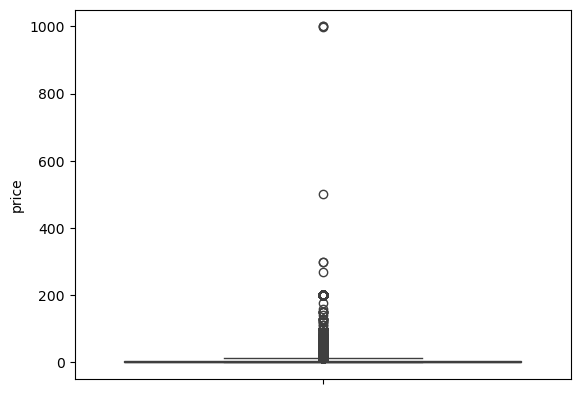

In [181]:
sns.boxplot(df["price"])

In [182]:
df[df["price"] <= 60] # вроде не подходит

,required_age,price,dlc_count,metacritic_score,metacritic_url,recommendations,supported_languages,full_audio_languages,positive,negative,...,genre_Casual,genre_Action,genre_Adventure,genre_Simulation,cat_Single-player,cat_Family Sharing,cat_Steam Achievements,cat_Steam Cloud,cat_Full controller support,peak_ccu_log
0,0,0.00,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.000000
1,0,5.24,0,0,0,231,1,0,252,3,...,0,0,1,0,0,0,0,0,0,0.000000
2,0,4.99,0,0,0,0,4,0,21,3,...,1,0,0,0,0,0,0,0,0,0.000000
3,0,8.99,1,0,0,0,1,1,0,0,...,1,0,0,1,0,0,0,0,0,0.693147
4,0,4.99,0,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122606,0,0.00,0,0,0,0,2,2,0,0,...,0,1,1,1,0,0,0,0,0,0.000000
122607,0,0.00,0,0,0,0,4,2,0,0,...,1,0,0,0,0,0,0,0,0,0.000000
122608,0,7.99,0,0,0,0,1,1,0,0,...,1,1,1,0,0,0,0,0,0,0.000000
122609,0,2.09,0,0,0,0,2,2,0,0,...,1,1,1,0,0,0,0,0,0,0.000000


In [183]:
df = df[df["price"] <= 60]

<Axes: ylabel='recommendations'>

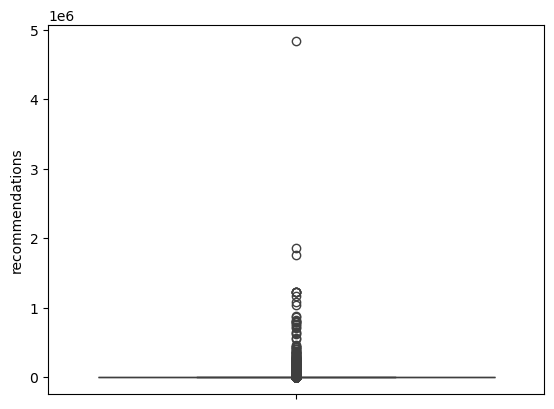

In [184]:
sns.boxplot(df["recommendations"]) # можно логарифмировать

In [185]:
df["recommendations"] = np.log1p(df["recommendations"])

In [186]:
df["recommendations"].describe()

count    122215.000000
mean          1.101067
std           2.511170
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          15.390451
Name: recommendations, dtype: float64

<Axes: ylabel='dlc_count'>

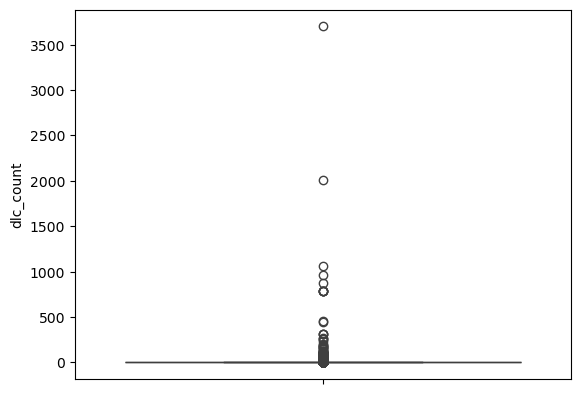

In [187]:
sns.boxplot(df["dlc_count"])

In [ ]:
df[df["dlc_count"] <= 100] # вроде подходит

,required_age,price,dlc_count,metacritic_score,metacritic_url,recommendations,supported_languages,full_audio_languages,positive,negative,...,genre_Casual,genre_Action,genre_Adventure,genre_Simulation,cat_Single-player,cat_Family Sharing,cat_Steam Achievements,cat_Steam Cloud,cat_Full controller support,peak_ccu_log
0,0,0.00,0,0,0,0.000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.000000
1,0,5.24,0,0,0,5.446737,1,0,252,3,...,0,0,1,0,0,0,0,0,0,0.000000
2,0,4.99,0,0,0,0.000000,4,0,21,3,...,1,0,0,0,0,0,0,0,0,0.000000
3,0,8.99,1,0,0,0.000000,1,1,0,0,...,1,0,0,1,0,0,0,0,0,0.693147
4,0,4.99,0,0,0,0.000000,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122606,0,0.00,0,0,0,0.000000,2,2,0,0,...,0,1,1,1,0,0,0,0,0,0.000000
122607,0,0.00,0,0,0,0.000000,4,2,0,0,...,1,0,0,0,0,0,0,0,0,0.000000
122608,0,7.99,0,0,0,0.000000,1,1,0,0,...,1,1,1,0,0,0,0,0,0,0.000000
122609,0,2.09,0,0,0,0.000000,2,2,0,0,...,1,1,1,0,0,0,0,0,0,0.000000


In [189]:
df = df[df["dlc_count"] <= 100]

In [ ]:
df["positive"] = np.log1p(df["positive"])

In [191]:
df["negative"] = np.log1p(df["negative"])

<Axes: ylabel='average_playtime_2weeks'>

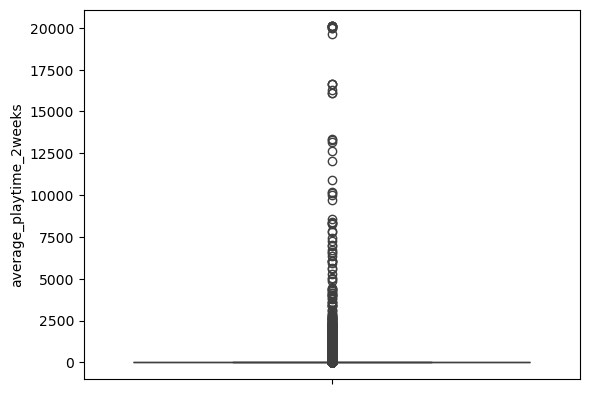

In [192]:
sns.boxplot(df["average_playtime_2weeks"]) # эта и 3 похожие колонки спорны крайне

In [194]:
# я хочу предсказывать онлайн и для новых игр тоже
df["average_playtime_forever"] = np.log1p(df["average_playtime_forever"])
df["average_playtime_2weeks"] = np.log1p(df["average_playtime_2weeks"])
df["median_playtime_forever"] = np.log1p(df["median_playtime_forever"])
df["median_playtime_2weeks"] = np.log1p(df["median_playtime_2weeks"])

In [ ]:
#переделать и сохранить)
